# Jour 2 · De l'erreur de prévision à une alerte

## Objectifs

- distinguer erreur signée, erreur absolue et score d'anomalie ;
- apprendre un seuil uniquement sur une période de référence passée ;
- transformer un dépassement de seuil en alerte ;
- distinguer vérité terrain, détection et diagnostic ;
- interpréter précision, rappel et F1 dans un contexte de maintenance.

## Le pont entre forecasting et anomalie

Prophet décrit le comportement qu'il considère comme attendu. Lorsque la mesure réelle s'en éloigne fortement, plusieurs explications sont possibles :

- un événement anormal affecte l'équipement ;
- une condition externe inhabituelle n'est pas connue du modèle ;
- le capteur est défaillant ;
- le modèle décrit mal le fonctionnement normal ;
- le procédé a durablement changé.

Une grande erreur est donc un **signal à investiguer**, jamais une preuve automatique de panne. Notre pipeline produit une alerte destinée à guider l'observation humaine.

## Trois notions à ne pas confondre

| Notion | Définition | Exemple |
|---|---|---|
| **Résidu signé** | observation moins prévision | +2 °C signifie que le modèle sous-estime de 2 °C |
| **Erreur absolue** | distance positive entre observation et prévision | 2 °C, quel que soit le sens |
| **Alerte** | décision obtenue après comparaison à un seuil | erreur supérieure à 1,4 °C |

Le signe aide à comprendre le phénomène. Pour détecter un écart important dans les deux directions, nous utilisons la valeur absolue.

~~~text
observation 24 °C, prévision 22 °C → résidu +2 °C → erreur absolue 2 °C
observation 20 °C, prévision 22 °C → résidu -2 °C → erreur absolue 2 °C
~~~

![Écarts verticaux entre une courbe observée et une courbe prévue](../assets/jour_02/03_residu_observe_prevu.png)

*Le résidu mesure ce que la prévision n'a pas expliqué. Sa valeur absolue peut servir de score d'anomalie simple.*

## Le rôle particulier de la vérité terrain

Le fichier utilisé ici contient une colonne is_anomaly créée lors de la génération des données synthétiques. Elle représente notre **vérité terrain** : nous savons quels instants ont été artificiellement perturbés.

Cette colonne sert uniquement à évaluer les alertes après coup. Elle n'est fournie ni à Prophet ni à la règle de seuil. Dans un projet réel, cette vérité pourrait venir des rapports de techniciens, des incidents enregistrés ou d'une validation manuelle. Elle est souvent incomplète.

Il faut donc distinguer :

- ce que le système **détecte** ;
- ce que les données de référence déclarent **anormal** ;
- la cause réelle confirmée lors du **diagnostic**.

## Étape 1 — préparer température et labels

Les mesures arrivent toutes les quinze minutes. Nous passons à l'heure avec deux agrégations différentes :

- moyenne pour résumer la température ;
- maximum pour le label, afin qu'une heure soit marquée anormale dès qu'au moins un quart d'heure l'était.

Utiliser la moyenne du label créerait une proportion difficile à comparer à une décision binaire.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from prophet import Prophet
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score


def find_project_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "datasets").is_dir():
            return candidate
    raise FileNotFoundError("Dossier datasets introuvable. Lancez Jupyter depuis le projet.")


ROOT = find_project_root()
DATA_DIR = ROOT / "datasets"
plt.style.use("seaborn-v0_8-whitegrid")

df = pd.read_csv(DATA_DIR / "prepared" / "iot_hvac_labeled.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

hourly = (
    df.set_index("timestamp")
    .resample("1h")
    .agg({
        "temperature_c": "mean",
        "is_anomaly": "max",
    })
)

print(hourly.head())
print("Heures observées :", len(hourly))
print("Heures labellisées anormales :", int(hourly["is_anomaly"].sum()))

C:\Users\bstorm_user\Desktop\time series\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


                           temperature_c  is_anomaly
timestamp                                           
2026-07-01 00:00:00+00:00       18.00050           0
2026-07-01 01:00:00+00:00       18.21175           0
2026-07-01 02:00:00+00:00       18.16950           0
2026-07-01 03:00:00+00:00       18.48450           0
2026-07-01 04:00:00+00:00       18.93725           0
Heures observées : 1008
Heures labellisées anormales : 75


## Étape 2 — définir une période de référence et une période d'évaluation

Nous utilisons les 28 premiers jours comme référence passée et les 14 jours suivants comme test chronologique. La période de référence est **majoritairement normale**, même si quelques points inhabituels peuvent s'y trouver.

Dans un système réel, choisir cette période est une décision importante :

- trop courte, elle représente mal les cycles habituels ;
- contenant une panne longue, elle peut apprendre cette panne comme normale ;
- trop ancienne, elle peut ne plus représenter l'équipement actuel.

Nous n'utilisons pas les labels pour nettoyer l'entraînement : ils restent réservés à l'évaluation.

In [2]:
cutoff = hourly.index.min() + pd.Timedelta(days=28)
train = hourly.loc[hourly.index < cutoff]
test = hourly.loc[hourly.index >= cutoff]

assert train.index.max() < test.index.min()

print("Référence :", train.index.min(), "→", train.index.max())
print("Évaluation :", test.index.min(), "→", test.index.max())
print("Anomalies labellisées dans la référence :", int(train["is_anomaly"].sum()))

Référence : 2026-07-01 00:00:00+00:00 → 2026-07-28 23:00:00+00:00
Évaluation : 2026-07-29 00:00:00+00:00 → 2026-08-11 23:00:00+00:00
Anomalies labellisées dans la référence : 5


C:\Users\bstorm_user\AppData\Local\Temp\ipykernel_187556\3326310461.py:1: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  cutoff = hourly.index.min() + pd.Timedelta(days=28)


## Étape 3 — apprendre le comportement attendu

Prophet reçoit uniquement la température de la période de référence. Il apprend sa tendance ainsi que ses cycles journaliers et hebdomadaires. La colonne is_anomaly reste absente de prophet_train.

Nous lui demandons ensuite une prévision pour toutes les dates afin de calculer :

- les erreurs de référence, nécessaires au choix du seuil ;
- les erreurs du test, nécessaires à l'évaluation future.

Prévoir les dates d'entraînement n'est pas une évaluation de performance. Cela sert ici à connaître la taille habituelle des résidus sur la référence.

In [3]:
prophet_train = (
    train["temperature_c"]
    .rename_axis("ds")
    .rename("y")
    .reset_index()
)
prophet_train["ds"] = prophet_train["ds"].dt.tz_localize(None)

model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False,
    uncertainty_samples=0,
)
model.fit(prophet_train)

all_dates = pd.DataFrame({
    "ds": hourly.index.tz_localize(None),
})
all_forecast = model.predict(all_dates)
hourly["forecast"] = all_forecast["yhat"].to_numpy()

07:34:20 - cmdstanpy - INFO - Chain [1] start processing


07:34:20 - cmdstanpy - INFO - Chain [1] done processing


## Étape 4 — construire le score d'anomalie

Nous conservons les deux formes du résidu :

- residual pour savoir si la température est au-dessus ou en dessous de l'attendu ;
- absolute_error pour mesurer uniquement la taille de l'écart.

Une erreur absolue élevée devient notre score d'anomalie. Ce score est continu : 0,2 °C est peu inhabituel, 3 °C l'est beaucoup plus. Il ne devient une alerte binaire qu'après application d'un seuil.

In [4]:
hourly["residual"] = hourly["temperature_c"] - hourly["forecast"]
hourly["absolute_error"] = hourly["residual"].abs()

columns = ["temperature_c", "forecast", "residual", "absolute_error"]
hourly[columns].head().round(3)

,temperature_c,forecast,residual,absolute_error
timestamp,,,,
2026-07-01 00:00:00+00:00,18.001,18.319,-0.319,0.319
2026-07-01 01:00:00+00:00,18.212,18.363,-0.151,0.151
2026-07-01 02:00:00+00:00,18.170,18.463,-0.294,0.294
2026-07-01 03:00:00+00:00,18.484,18.639,-0.155,0.155
2026-07-01 04:00:00+00:00,18.937,18.966,-0.029,0.029


## Étape 5 — apprendre un seuil sans regarder le futur

Nous choisissons le quantile 0,99 des erreurs de référence. Cela signifie qu'environ 99 % de ces erreurs sont inférieures ou égales au seuil et qu'environ 1 % sont plus grandes.

Le quantile est utile ici parce qu'il :

- s'adapte à l'échelle réelle des résidus ;
- tolère quelques erreurs élevées dans la référence ;
- se comprend comme un taux d'alertes potentiel sur un comportement similaire.

Le choix de 0,99 n'est pas magique. Un seuil plus bas détecte davantage d'événements mais déclenche aussi davantage de fausses alertes. Surtout, le seuil doit être calculé sur le passé uniquement. Utiliser les erreurs du test pour le choisir serait une fuite de données.

In [5]:
reference_errors = hourly.loc[hourly.index < cutoff, "absolute_error"]
threshold = reference_errors.quantile(0.99)

hourly["detected"] = (hourly["absolute_error"] > threshold).astype(int)

print(f"Seuil appris sur la référence : {threshold:.2f} °C")
print("Part des heures de référence au-dessus du seuil :",
      f"{hourly.loc[hourly.index < cutoff, 'detected'].mean():.1%}")

Seuil appris sur la référence : 0.71 °C
Part des heures de référence au-dessus du seuil : 1.0%


![Erreur absolue comparée à un seuil avec points d'alerte](../assets/jour_02/03_erreur_seuil_alerte.png)

*Le score reste continu. La ligne de seuil transforme seulement les plus grands écarts en alertes à examiner.*

## Étape 6 — confronter les alertes à la vérité terrain

Pour chaque heure du test, quatre situations sont possibles :

| Réalité | Détection | Nom | Lecture |
|---|---|---|---|
| anomalie | alerte | vrai positif | événement correctement signalé |
| normale | alerte | faux positif | fausse alerte |
| anomalie | aucune alerte | faux négatif | anomalie manquée |
| normale | aucune alerte | vrai négatif | fonctionnement normal correctement ignoré |

Le détecteur ne lit jamais cette table pendant son fonctionnement. Nous l'utilisons après coup pour évaluer ses décisions.

![Matrice expliquant vrais positifs, faux positifs, faux négatifs et vrais négatifs](../assets/jour_02/03_precision_et_rappel.png)

*La précision regarde la qualité des alertes envoyées ; le rappel regarde la couverture des anomalies réelles.*

## Précision, rappel et F1 en langage métier

### Précision

Parmi les alertes envoyées, quelle proportion correspond vraiment à une anomalie ? Une faible précision surcharge les techniciens de fausses alertes et finit par réduire leur confiance.

### Rappel

Parmi toutes les anomalies connues, quelle proportion avons-nous détectée ? Un faible rappel laisse passer des événements potentiellement importants.

### F1

F1 résume précision et rappel dans un seul nombre. Il est utile pour comparer des essais, mais il ne connaît pas le coût réel d'une panne manquée ni celui d'une intervention inutile.

Baisser le seuil augmente généralement le rappel et diminue la précision. Le bon compromis dépend donc du risque métier.

In [6]:
evaluation = hourly.loc[hourly.index >= cutoff].copy()
y_true = evaluation["is_anomaly"]
y_pred = evaluation["detected"]

precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print(f"Précision : {precision:.3f}")
print(f"Rappel    : {recall:.3f}")
print(f"F1        : {f1:.3f}")
print()
print(f"Vrais positifs : {tp} | Faux positifs : {fp}")
print(f"Faux négatifs : {fn} | Vrais négatifs : {tn}")

Précision : 0.917
Rappel    : 0.314
F1        : 0.468

Vrais positifs : 22 | Faux positifs : 2
Faux négatifs : 48 | Vrais négatifs : 264


### Comment interpréter ces résultats ?

Ne cherchez pas seulement le plus grand score. Traduisez les comptes en conséquences :

- combien d'alertes un technicien recevrait-il sur deux semaines ?
- combien seraient inutiles ?
- combien d'heures anormales resteraient invisibles ?
- plusieurs alertes consécutives correspondent-elles à un seul incident ?

Une métrique calculée heure par heure peut compter dix heures d'une même panne comme dix anomalies. En production, on regrouperait souvent les alertes proches en incidents.

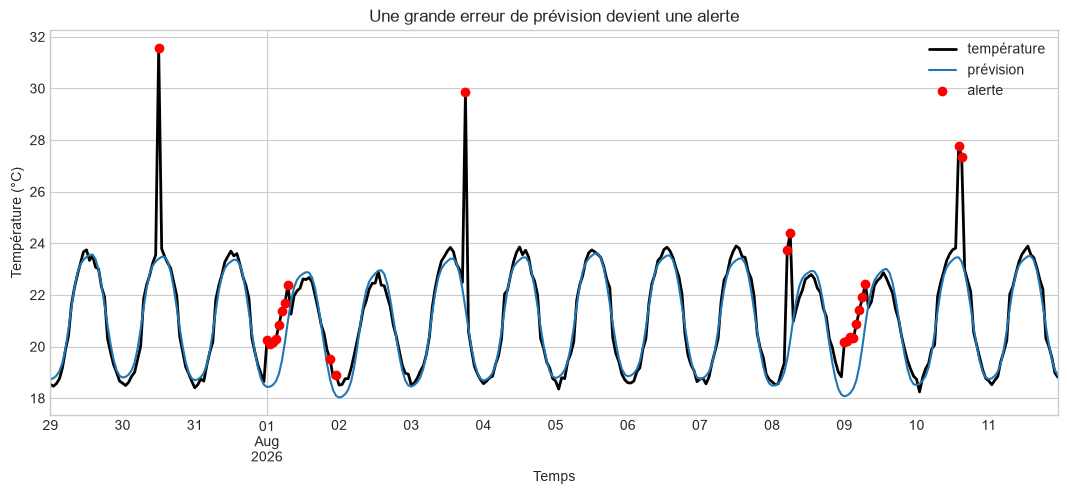

In [7]:
view = hourly.loc[hourly.index >= cutoff]
ax = view["temperature_c"].plot(
    figsize=(13, 5), label="température", color="black", linewidth=2
)
view["forecast"].plot(ax=ax, label="prévision", color="tab:blue")
detected = view[view["detected"] == 1]
ax.scatter(
    detected.index,
    detected["temperature_c"],
    color="red",
    label="alerte",
    zorder=3,
)
ax.set_ylabel("Température (°C)")
ax.set_xlabel("Temps")
ax.set_title("Une grande erreur de prévision devient une alerte")
ax.legend()
plt.show()

## Les limites de cette détection

Une erreur de prévision élevée peut venir du système ou du modèle. Avant une mise en production, il faudrait notamment surveiller :

- les données absentes ou bloquées ;
- un changement durable de régime ;
- l'évolution de la distribution des résidus ;
- le nombre d'alertes par jour ;
- les retours des techniciens ;
- la version du modèle et la valeur du seuil.

Le seuil devrait être réévalué de manière contrôlée, pas recalculé automatiquement sur n'importe quelle période : une panne longue pourrait sinon devenir progressivement la nouvelle normalité.

### À vous de jouer — comparer plusieurs seuils

Comparez les quantiles 0,98, 0,99 et 0,995 calculés sur reference_errors. Construisez un tableau contenant quantile, seuil, nombre d'alertes dans le test, précision, rappel et F1.

**Contrôles attendus :** lorsque le quantile augmente, le seuil ne diminue pas ; le nombre d'alertes baisse généralement ; toutes les métriques sont calculées sur le même test.

**Question :** quel compromis choisiriez-vous si manquer une surchauffe coûte beaucoup plus cher qu'une inspection inutile ?

In [8]:
# Écrivez votre code ici.
pass

### À vous de jouer — utiliser le signe du résidu

Séparez les alertes du test en deux groupes : température supérieure à la prévision et température inférieure à la prévision. Comptez chaque groupe et affichez leurs cinq plus grandes erreurs.

**Question d'interprétation :** ces deux directions pourraient-elles correspondre aux mêmes causes de maintenance ?

**Indice :** utilisez le signe de la colonne residual uniquement après avoir sélectionné les alertes.

In [9]:
# Écrivez votre code ici.
pass

### À vous de jouer — décider comme une équipe de maintenance

Deux réglages sont proposés :

- réglage A : précision élevée, mais rappel de 45 % ;
- réglage B : rappel élevé, mais deux fois plus de fausses alertes.

Choisissez un réglage pour chacun des cas suivants et justifiez votre décision :

1. surveillance d'une chambre froide contenant des produits sensibles ;
2. surveillance du confort d'une salle de réunion ;
3. capteur difficile d'accès nécessitant une intervention coûteuse.

Il n'existe pas une réponse universelle : explicitez le coût que vous cherchez à réduire.

In [10]:
# Notez ici votre décision sous forme de commentaires.
pass

## À retenir

- Le résidu signé conserve le sens de l'écart ; l'erreur absolue en conserve la taille.
- Une grande erreur est un signal inhabituel, pas un diagnostic de panne.
- Le seuil doit être appris sur une référence passée, jamais optimisé sur le futur évalué.
- Baisser le seuil augmente généralement les détections et les fausses alertes.
- La précision mesure la fiabilité des alertes ; le rappel mesure la couverture des anomalies.
- Le compromis final dépend du coût métier et du retour des techniciens.

### La chaîne complète

~~~text
passé majoritairement normal → modèle du comportement attendu
                            → résidu → erreur absolue → seuil
                            → alerte → évaluation → investigation humaine
~~~